In [1]:
import os
import re
import json

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import differential_evolution, nnls
import torch

from core.data import load_dataset, split_dataset, CLASS_TO_IDX
from core.utils import seed_everything, make_generator

plt.rcParams.update({"legend.fontsize": 8,
                     "axes.titlesize": 10})

In [2]:
# params
device = torch.device("cuda" if torch.cuda.is_available() else
                      "mps"  if torch.backends.mps.is_available() else "cpu")
REGION = ["mouth", "nose"]
SEED = 0
NUM_EPOCHS = 500
BATCH_SIZE = 16
LR = 1e-3 
BETA_MAX = 0.1
LAMBDA_SPARSITY = 0.001
LAMBDA_BASELINE = 1.0
TAU_S = 15.0
CKPT_PATH = "results/pinn/best_checkpoint.pt"
os.makedirs("results/pinn", exist_ok=True)

# reproducibility
seed_everything(SEED)
g = make_generator(SEED)

### Physical Model

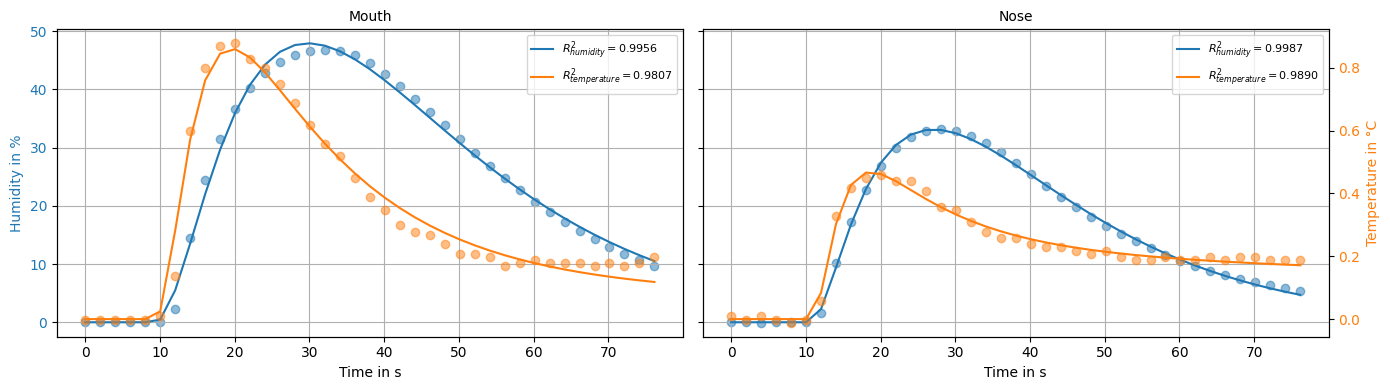

────────────────────────────────────────────
Parameter                Mouth          Nose
────────────────────────────────────────────
Humidity
  A                     5.2581        4.6596
  D (m²/s)            2.51e-05      4.48e-05
  v (m/s)               0.0023        0.0034
  t_shift (s)           6.3434        8.4042
Temperature
  A                     0.1445        0.2238
  tau_fast (s)          1.9804        1.7221
  alpha                 0.6113        0.2298
  tau_slow (s)        250.0000      250.0000
────────────────────────────────────────────


In [14]:
# fit advection-diffusion-sensor model to sir data
def load_sir(dataset_dir="dataset"):
    dataset = []
    folder = os.path.join(dataset_dir, "sir")

    # loop through all .dat files
    for fname in sorted(os.listdir(folder)):
        if not fname.endswith(".dat"):
            continue

        # extract metadata
        m = re.match(r"^(mouth|nose)_trial_(\d+)\.dat$", fname)
        if m is None:
            continue
        
        # load the data
        df = pd.read_csv(os.path.join(folder, fname))
        dataset.append({"filename": fname,
                        "region": m.group(1),
                        "trial_num": int(m.group(2)),
                        "time": df["Time"].values/1000,
                        "humidity": df["Humidity"].values,
                        "temperature": df["Temperature"].values})

    return pd.DataFrame(dataset)

def preprocess_cir(humidity, temperature):
    # compute baseline
    baseline_h = np.mean(humidity[:6])
    baseline_t = np.mean(temperature[:6])

    # remove baseline
    humidity_baseline_corrected = humidity - baseline_h
    temperature_baseline_corrected = temperature - baseline_t

    return humidity_baseline_corrected, temperature_baseline_corrected

def cir_stats(df):
    # stack data
    humidity_all = np.stack(df["humidity"].values)
    temperature_all = np.stack(df["temperature"].values)

    # gets stats
    mean_humidity = np.mean(humidity_all, axis=0)
    mean_temperature = np.mean(temperature_all, axis=0)
    std_humidity = np.std(humidity_all, axis=0)
    std_temperature = np.std(temperature_all, axis=0)

    return mean_humidity, mean_temperature, std_humidity, std_temperature

def advection_diffusion(time, A , D, v, t_shift, d0=0.03):
    t = np.asarray(time, dtype=float)
    out = np.zeros_like(t)

    # shift time 
    t_model = t - t_shift
    mask = t_model > 1e-9
    tt = t_model[mask]

    # formula
    prefactor = A / np.sqrt(4.0 * np.pi * D * tt)
    exponent  = -((d0 - v * tt) ** 2) / (4.0 * D * tt)
    out[mask] = prefactor * np.exp(exponent)
    
    return out

def sensor_kernel(t, tau_s=15.0):
    s = np.where(t > 0, (1.0 / tau_s) * np.exp(-t / tau_s), 0.0)
    return s

def sensor_kernel_biexp(t, tau_fast, alpha, tau_slow):
    fast = (alpha / tau_fast) * np.exp(-t / tau_fast)
    slow = ((1.0 - alpha) / tau_slow) * np.exp(-t / tau_slow)
    s = np.where(t > 0, fast + slow, 0.0)
    return s

def system_impulse_response(time, A, D, v, t_shift, sensor_fn):
    t = np.asarray(time, dtype=float)
    dt = t[1] - t[0] # assume uniform sampling
    t_kernel = np.arange(0, t[-1] + dt, dt)

    # advection-diffusion channel
    cir = advection_diffusion(t, A, D, v, t_shift)

    # sensor response
    s = sensor_fn(t_kernel)

    # convolution
    sir = np.convolve(cir, s, mode="full")[:len(t)] * dt
    return sir

def fit_sir(signal, tau_s_humidity=15.0):
    time = signal["time"]
    h, t_data = preprocess_cir(signal["humidity"], signal["temperature"])

    # humidity
    sensor_h = lambda tk: sensor_kernel(tk, tau_s_humidity)
    def obj_h(params, t, h):
        A, D, v, ts = params
        pred = system_impulse_response(t, A, D, v, ts, sensor_h)
        return np.mean((pred - h) ** 2)
    bounds_h = [(1e-3, 1e3), (1e-7, 1e-2), (0.0, 1e-1), (0.0, 15.0)] # A, D, v, t_shift
    res_h = differential_evolution(obj_h, bounds=bounds_h, args=(time, h), seed=SEED, tol=1e-8, maxiter=1000, polish=True)
    A_h, D, v, t_shift = res_h.x

    # temperature
    def obj_t(params, t, td):
        A, tau_fast, alpha, tau_slow = params
        sensor_t = lambda tk: sensor_kernel_biexp(tk, tau_fast, alpha, tau_slow)
        pred = system_impulse_response(t, A, D, v, t_shift, sensor_t)
        return np.mean((pred - td) ** 2)
    bounds_t = [(1e-3, 1e2), (0.5, 5.0), (0.2, 0.95), (30.0, 250.0)] # A, tau_fast, alpha, tau_slow
    res_t = differential_evolution(obj_t, bounds=bounds_t, args=(time, t_data), seed=SEED, tol=1e-8, maxiter=1000, polish=True)

    return res_h.x, res_t.x

# load data
df_sir = load_sir()

# fitting
mean_then_fit = {}
fig, ax = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
ax_twin = [ax[0].twinx(), ax[1].twinx()]
ax_twin[1].sharey(ax_twin[0])
ax_twin[0].tick_params(right=False, labelright=False)
for col, region in enumerate(REGION):
    df_region = df_sir[df_sir["region"] == region]
    time = df_region.iloc[0]["time"]

    # mean over trials
    humidity_mean, temperature_mean, _, _ = cir_stats(df_region)
    signal = dict(time=time, humidity=humidity_mean, temperature=temperature_mean)

    # fit model to mean signal
    params_humidity, params_temperature = fit_sir(signal)
    A_h, D, v, t_shift = params_humidity
    A_t, tau_fast, alpha, tau_slow = params_temperature

    # build sensor kernel
    sensor_h = lambda tk: sensor_kernel(tk, tau_s=15.0)
    sensor_t = lambda tk: sensor_kernel_biexp(tk, tau_fast, alpha, tau_slow)

    # compute solution
    solution_humidity = system_impulse_response(time, A_h, D, v, t_shift, sensor_h)
    solution_temperature = system_impulse_response(time, A_t, D, v, t_shift, sensor_t)
    humidity_baseline_corrected, temperature_baseline_corrected = preprocess_cir(humidity_mean, temperature_mean)

    # compute r^2
    ss_res_h = np.sum((humidity_baseline_corrected - solution_humidity) ** 2)
    ss_res_t = np.sum((temperature_baseline_corrected - solution_temperature) ** 2)
    ss_tot_h = np.sum((humidity_baseline_corrected - np.mean(humidity_baseline_corrected)) ** 2)
    ss_tot_t = np.sum((temperature_baseline_corrected - np.mean(temperature_baseline_corrected)) ** 2)
    r2_humidity = 1 - ss_res_h / ss_tot_h
    r2_temperature = 1 - ss_res_t / ss_tot_t

    # store fit parameters
    mean_then_fit[region] = {"humidity_params": params_humidity,
                             "temperature_params": params_temperature,
                             "r2_humidity": r2_humidity,
                             "r2_temperature": r2_temperature}

    # humidity
    ax[col].scatter(time, humidity_baseline_corrected, marker="o", color="tab:blue", alpha=0.5)
    ax[col].plot(time, solution_humidity, label=rf"$R^2_{{humidity}}=${r2_humidity:.4f}", color="tab:blue")
    ax[col].set_xlabel("Time in s")
    ax[col].tick_params(axis="y", labelcolor="tab:blue")
    ax[col].grid()

    # temperature
    ax_twin[col].scatter(time, temperature_baseline_corrected, marker="o", color="tab:orange", alpha=0.5)
    ax_twin[col].plot(time, solution_temperature, label=rf"$R^2_{{temperature}}=${r2_temperature:.4f}", color="tab:orange",)
    ax_twin[col].tick_params(axis="y", labelcolor="tab:orange")

    ax[0].set_ylabel("Humidity in %", color="tab:blue")
    ax_twin[1].set_ylabel("Temperature in °C", color="tab:orange")
    h1, l1 = ax[col].get_legend_handles_labels()
    h2, l2 = ax_twin[col].get_legend_handles_labels()
    ax[col].legend(h1 + h2, l1 + l2, loc="upper right")
    ax[col].set_title(f"{region.capitalize()}")

plt.tight_layout()
plt.show()

# print
header = f"{'Parameter':<16}{'Mouth':>14}{'Nose':>14}"
sep    = "─" * len(header)
print(sep)
print(header)
print(sep)
print("Humidity")
rows_h = [("  A",         "{:.4f}",   "humidity_params", 0),
          ("  D (m²/s)",  "{:.2e}",   "humidity_params", 1),
          ("  v (m/s)",   "{:.4f}",   "humidity_params", 2),
          ("  t_shift (s)","{:.4f}",  "humidity_params", 3)]
for label, fmt, key, idx in rows_h:
    m = fmt.format(mean_then_fit["mouth"][key][idx])
    n = fmt.format(mean_then_fit["nose"][key][idx])
    print(f"{label:<16}{m:>14}{n:>14}")

print("Temperature")
rows_t = [("  A",          "{:.4f}", "temperature_params", 0),
          ("  tau_fast (s)","{:.4f}","temperature_params", 1),
          ("  alpha",      "{:.4f}", "temperature_params", 2),
          ("  tau_slow (s)","{:.4f}","temperature_params", 3)]
for label, fmt, key, idx in rows_t:
    m = fmt.format(mean_then_fit["mouth"][key][idx])
    n = fmt.format(mean_then_fit["nose"][key][idx])
    print(f"{label:<16}{m:>14}{n:>14}")
print(sep)

# # save params
# np.save("results/pinn/params_mouth.npy", mean_then_fit["mouth"]["humidity_params"])
# np.save("results/pinn/params_nose.npy", mean_then_fit["nose"]["humidity_params"])

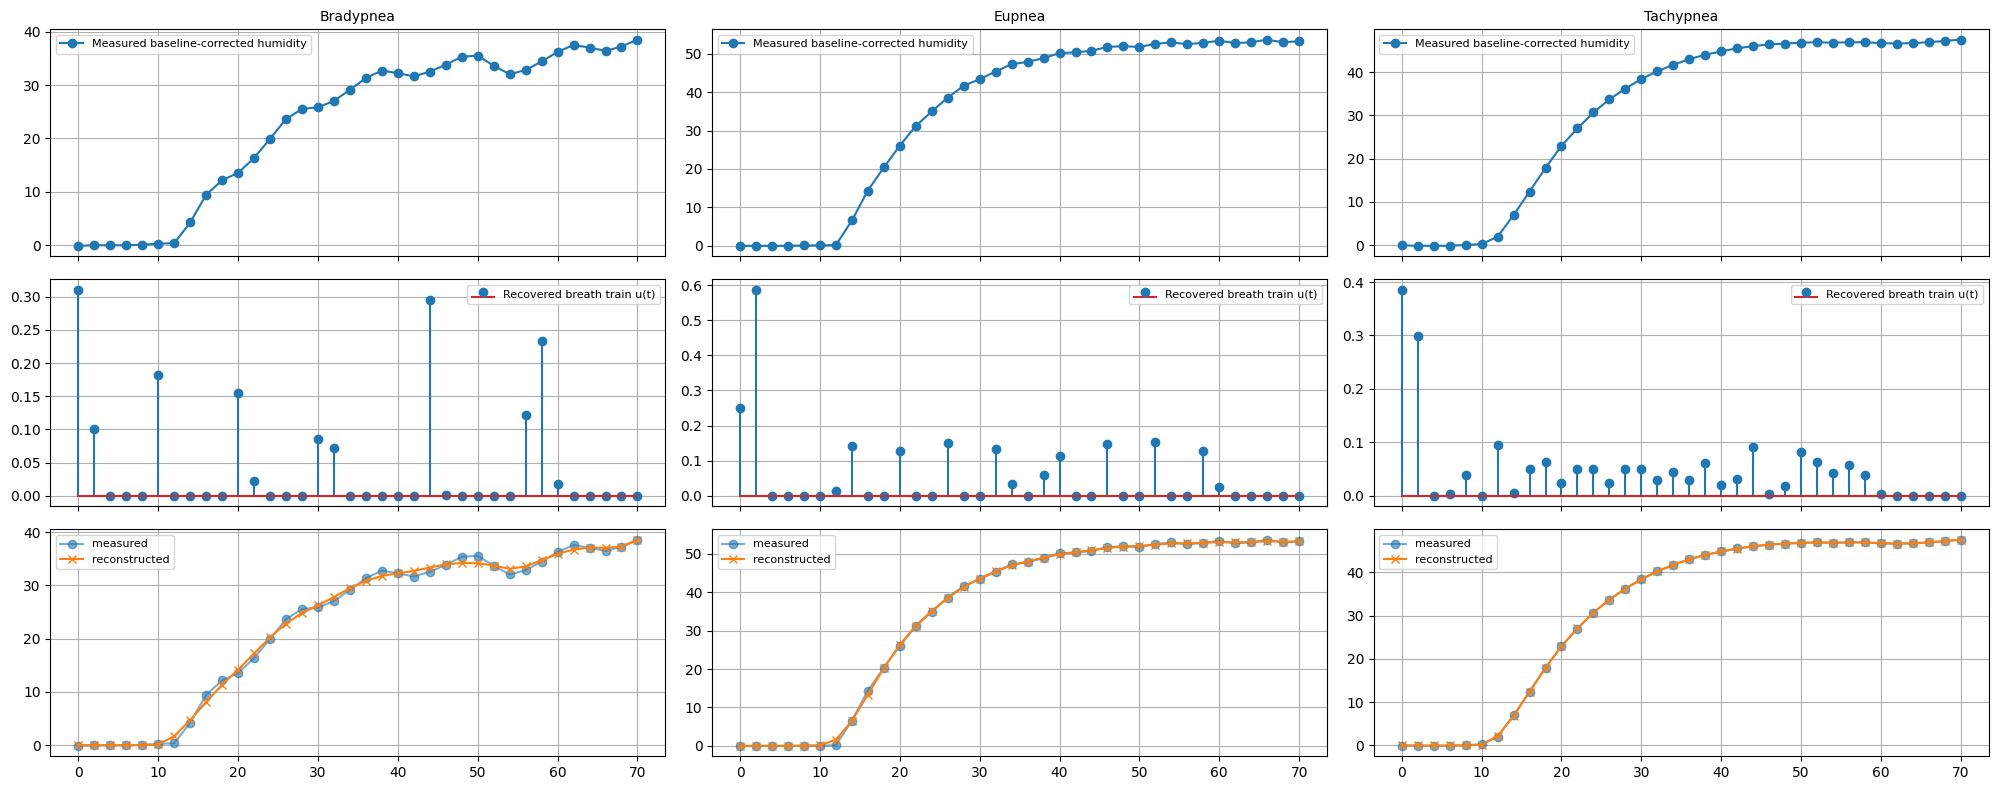

In [8]:
# deconvolution
def cir_kernel(time_grid, A, D, v, t_shift, tau_s):
    cir = advection_diffusion(time_grid, A, D, v, t_shift)
    dt = time_grid[1] - time_grid[0]
    t_kernel = np.arange(0, time_grid[-1] + dt, dt)
    s = sensor_kernel(t_kernel, tau_s)
    kernel = np.convolve(cir, s, mode="full")[:len(time_grid)] * dt
    return kernel

def deconvolve_nnls(y, h, N, lam=0.1):
    # build conv matrix
    H = np.zeros((N, N))
    for i in range(N):
        for j in range(i + 1):
            if i - j < len(h):
                H[i, j] = h[i - j]

    # solve nnls with tikhonov regularization
    H_aug = np.vstack([H, np.sqrt(lam) * np.eye(N)])
    y_aug = np.concatenate([y, np.zeros(N)])
    u, residual = nnls(H_aug, y_aug)
    return u

# load data
df = load_dataset("dataset")
df = df[df["region"] == region].reset_index(drop=True)
df_train, df_val, df_test = split_dataset(df, random_state=SEED)

# define cir param
params_mouth = mean_then_fit["mouth"]["humidity_params"]
time = np.arange(36)*2.0

cir_kernel_mouth = cir_kernel(time, *params_mouth, tau_s=15.0)
fig, axes = plt.subplots(3, 3, figsize=(20, 8), sharex=True)

for i, cls in enumerate(CLASS_TO_IDX.keys()):
    # get sample
    sample = df[df["class"] == cls].iloc[0]
    humidity = sample["humidity"]
    temperature = sample["temperature"]

    # preprocess
    humidity_baseline_corrected, _ = preprocess_cir(humidity, temperature)

    # deconvolve
    signal_recovered = deconvolve_nnls(humidity_baseline_corrected, cir_kernel_mouth, N=36, lam=0.5)

    # plot
    axes[0][i].plot(time, humidity_baseline_corrected, "o-", label="Measured baseline-corrected humidity")
    axes[0][i].grid()
    axes[0][i].legend(loc="upper left")
    axes[0][i].set_title(f"{cls.capitalize()}")
    
    axes[1][i].stem(time, signal_recovered, label="Recovered breath train u(t)")
    axes[1][i].grid()
    axes[1][i].legend(loc="upper right")
    
    y_reconstructed = np.convolve(signal_recovered, cir_kernel_mouth)[:36]
    axes[2][i].plot(time, humidity_baseline_corrected, "o-", label="measured", alpha=0.6)
    axes[2][i].plot(time, y_reconstructed, "x-", label="reconstructed")
    axes[2][i].legend()
    axes[2][i].grid()

plt.tight_layout()
plt.show()

### Training diagnostics

run: mouth_s0_ld16_ed8_phys0.0
best val_recon: 0.0052 at epoch 365
final  | recon t/v: 0.0083/0.0087  phys t/v: 0.0855/0.0833  ||u|| t/v: 4.002/3.910


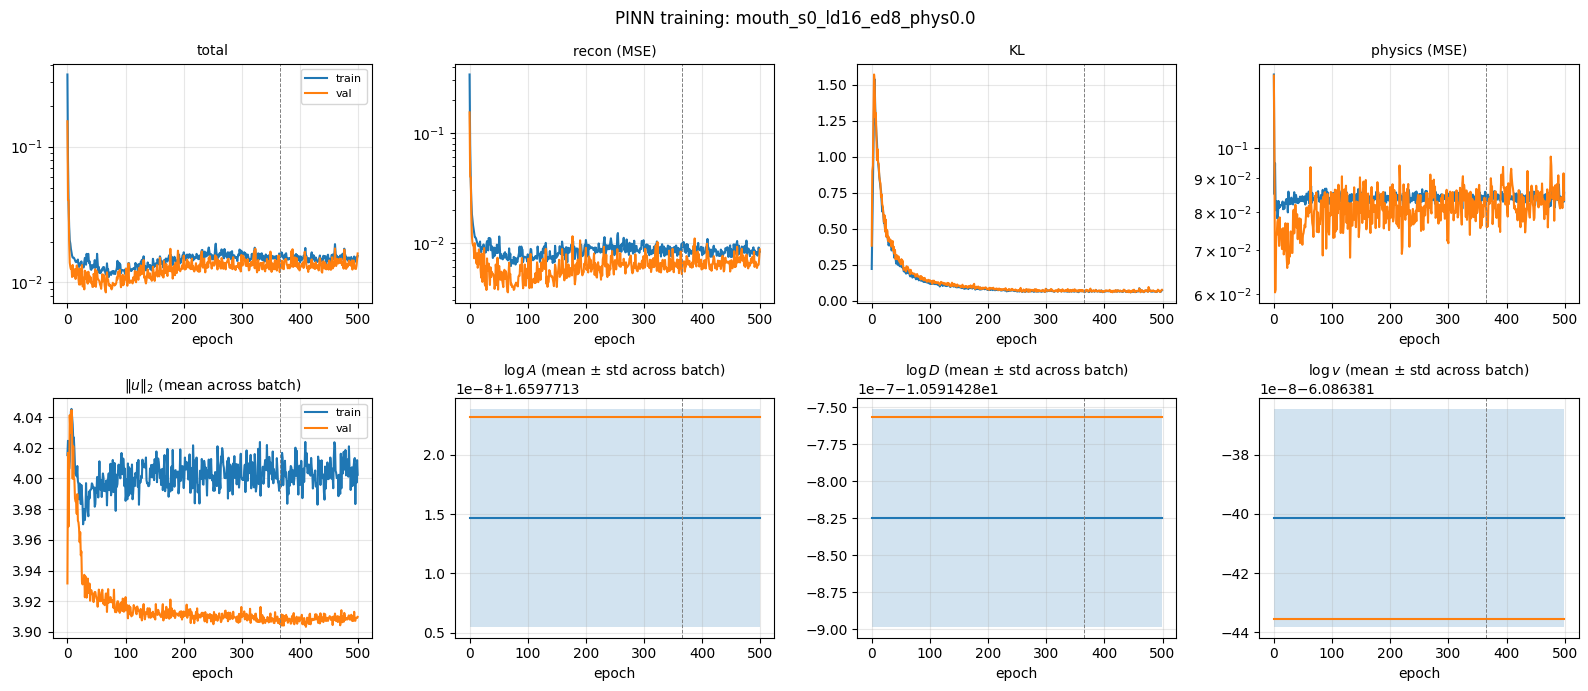

In [3]:
region = "mouth"
seed = 0
lambda_phys = 0.0
run_id = f"{region}_s{seed}_ld16_ed8_phys{lambda_phys}"
with open(f"results/pinn/{run_id}_history.json") as f:
    payload = json.load(f)
history = payload["history"]
best_epoch = payload["best_epoch"]
best_val_recon = payload["best_val_recon"]
epochs = np.arange(len(history["train_total"]))

print(f"run: {run_id}")
print(f"best val_recon: {best_val_recon:.4f} at epoch {best_epoch}")
print(
    f"final  | recon t/v: {history['train_recon'][-1]:.4f}/{history['val_recon'][-1]:.4f}"
    f"  phys t/v: {history['train_phys'][-1]:.4f}/{history['val_phys'][-1]:.4f}"
    f"  ||u|| t/v: {history['train_u_norm'][-1]:.3f}/{history['val_u_norm'][-1]:.3f}"
)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

loss_panel = [("total", "total", True), ("recon", "recon (MSE)", True),
              ("kl", "KL", False), ("phys", "physics (MSE)", True)]
for ax, (k, title, log_y) in zip(axes[0], loss_panel):
    ax.plot(epochs, history[f"train_{k}"], label="train")
    ax.plot(epochs, history[f"val_{k}"], label="val")
    ax.axvline(best_epoch, color="grey", lw=0.7, ls="--")
    ax.set_title(title)
    ax.set_xlabel("epoch")
    if log_y:
        ax.set_yscale("log")
    ax.grid(True, alpha=0.3)
axes[0][0].legend()

axes[1][0].plot(epochs, history["train_u_norm"], label="train")
axes[1][0].plot(epochs, history["val_u_norm"], label="val")
axes[1][0].axvline(best_epoch, color="grey", lw=0.7, ls="--")
axes[1][0].set_title(r"$\|u\|_2$ (mean across batch)")
axes[1][0].set_xlabel("epoch")
axes[1][0].grid(True, alpha=0.3)
axes[1][0].legend()

for ax, name, label in zip(axes[1][1:], ["logA", "logD", "logv"], [r"$\log A$", r"$\log D$", r"$\log v$"]):
    tmean = np.array(history[f"train_{name}_mean"])
    tstd  = np.array(history[f"train_{name}_std"])
    vmean = np.array(history[f"val_{name}_mean"])
    vstd  = np.array(history[f"val_{name}_std"])
    ax.plot(epochs, tmean, label="train")
    ax.fill_between(epochs, tmean - tstd, tmean + tstd, alpha=0.2)
    ax.plot(epochs, vmean, label="val")
    ax.fill_between(epochs, vmean - vstd, vmean + vstd, alpha=0.2)
    ax.axvline(best_epoch, color="grey", lw=0.7, ls="--")
    ax.set_title(f"{label} (mean ± std across batch)")
    ax.set_xlabel("epoch")
    ax.grid(True, alpha=0.3)

fig.suptitle(f"PINN training: {run_id}")
fig.tight_layout()
plt.show()

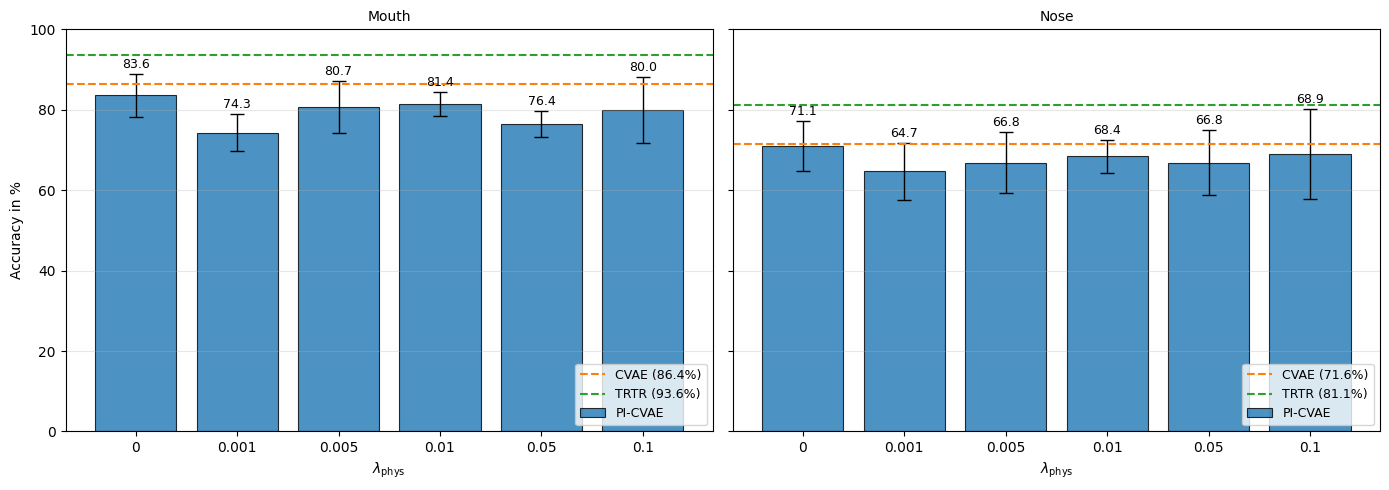

In [8]:
result_summary = pd.read_csv("./results/summary.csv")

df_pinn_mouth = result_summary[(result_summary["model"]=="pinn") & (result_summary["region"]=="mouth")]
df_pinn_nose = result_summary[(result_summary["model"]=="pinn") & (result_summary["region"]=="nose")]

# plot accuracy over physics lambda (mean and std)
# aggregate per lambda_phys (mean ± std across seeds)
def aggregate(df):
    agg = (df.groupby("lambda_phys")["accuracy"]
             .agg(["mean", "std", "count"])
             .reset_index()
             .sort_values("lambda_phys")
             .reset_index(drop=True))
    return agg

mouth_agg = aggregate(df_pinn_mouth)
nose_agg  = aggregate(df_pinn_nose)

# reference lines — update with your final numbers
CVAE_BASELINE = {"mouth": 86.43, "nose": 71.58}
TRTR_CEILING  = {"mouth": 93.6,  "nose": 81.1}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, agg, region in zip(axes, [mouth_agg, nose_agg], ["mouth", "nose"]):
    x = np.arange(len(agg))
    means = agg["mean"].values * 100
    stds  = agg["std"].values  * 100

    # bars with error bars
    ax.bar(x, means, yerr=stds, capsize=5, color="tab:blue", alpha=0.8,
           edgecolor="black", linewidth=0.8,
           error_kw=dict(ecolor="black", lw=1), label="PI-CVAE")

    # value labels above bars
    for i, (m, s) in enumerate(zip(means, stds)):
        ax.text(i, m + s + 1.5, f"{m:.1f}", ha="center", fontsize=9)

    # reference lines
    ax.axhline(CVAE_BASELINE[region], color="tab:orange", linestyle="--",
               linewidth=1.5, label=f"CVAE ({CVAE_BASELINE[region]:.1f}%)")
    ax.axhline(TRTR_CEILING[region], color="tab:green", linestyle="--",
               linewidth=1.5, label=f"TRTR ({TRTR_CEILING[region]:.1f}%)")

    ax.set_xticks(x)
    ax.set_xticklabels([f"{lam:g}" for lam in agg["lambda_phys"]])
    ax.set_xlabel(r"$\lambda_{\mathrm{phys}}$")
    ax.set_title(region.capitalize())
    ax.grid(axis="y", alpha=0.3)
    ax.set_ylim(0, 100)
    ax.legend(loc="lower right", fontsize=9)

axes[0].set_ylabel("Accuracy in %")

plt.tight_layout()
plt.show()


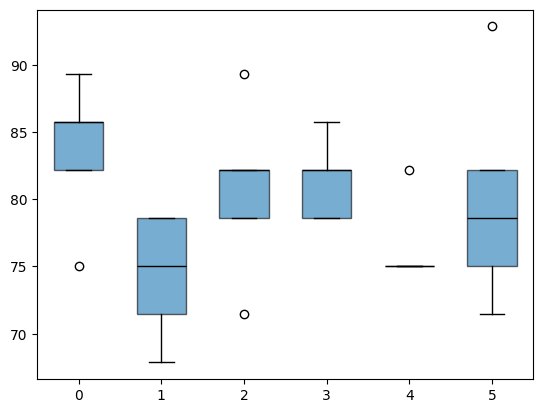

In [ ]:

df_pinn_mouth = result_summary[(result_summary["model"]=="pinn") & (result_summary["region"]=="mouth")]
df_pinn_nose = result_summary[(result_summary["model"]=="pinn") & (result_summary["region"]=="nose")]

df = df_pinn_mouth  # or df_pinn_nose for the nose region

plt.figure()
data_per_lambda = [df[df["lambda_phys"]==lam]["accuracy"].values*100 for lam in agg["lambda_phys"]]
plt.boxplot(data_per_lambda, positions=x, widths=0.6, patch_artist=True,
           boxprops=dict(facecolor="tab:blue", alpha=0.6),
           medianprops=dict(color="black"))
plt.show()

- how should I test my accuracy? should I run it across different seeds -> 